In [24]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'


In [25]:
 
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_calc_output = mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata.txt'
# Generate loop_info DataFrame

In [26]:
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

In [27]:
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
for i in range (df.shape[0]):
    pth_way = df.iloc[i].Path
    #get shelf area
    pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/iareafl/computed_iareafl_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'

    d = xr.open_dataset(pth_way,decode_times=False )
    d2 = xr.open_dataset(pth_area,decode_times=False )
    tmin = np.min([d.time.size,d2.time.size])
    
    y =d.shelfmelt.values[:tmin]/d2.iareafl.values[:tmin]
    for j in range(1,19):
        x =d['shelfmelt_sector_'+str(j)].values[:tmin]/d2['iareafl_sector_'+str(j)].values[:tmin]
        correlation_matrix = np.corrcoef(x, y)
        correlation_coefficient = correlation_matrix[0, 1]
        df['sector_'+str(j)].iloc[i] = correlation_coefficient


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_37484/127429607.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sector_'+str(j)].iloc[i] = correlation_coefficient
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_37484/127429607.py:30: RuntimeWarning: invalid value encountered in divide
  x =d['shelfmelt_sector_'+str(j)].values[:tmin]/d2['iareafl_sector_'+str(j)].values[:tmin]


In [28]:
df_sectors= df.copy()
df2 = df.copy()
df_sectors.drop(columns=['Experiment','Model','Path'], inplace=True)

In [29]:
df_sectors

,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,sector_8,sector_9,sector_10,sector_11,sector_12,sector_13,sector_14,sector_15,sector_16,sector_17,sector_18
0,0.851668,0.940732,0.859172,0.857741,0.899498,0.941777,0.850633,0.854547,0.889913,0.815463,0.671169,0.845086,0.756131,0.847680,0.864064,0.834588,0.760854,0.787771
1,0.943876,0.842032,0.945053,0.953786,0.954892,0.869103,0.952793,0.956130,0.954904,0.861901,0.865463,0.870258,0.940074,0.928080,0.847845,0.785491,0.812789,0.956632
2,0.868480,0.982618,0.841923,0.797936,0.960468,0.979538,0.928729,0.836160,0.914478,0.849459,0.940780,0.940602,0.818932,0.878851,0.901954,0.924421,0.905357,0.836857
3,0.953993,0.986106,0.954726,0.928911,0.898560,0.897836,0.916416,0.881588,0.893737,0.960947,0.848796,0.948594,0.958740,0.938925,0.974558,0.910526,NaN,0.942904
4,NaN,0.970758,0.956233,0.965010,0.741083,0.873934,0.957105,0.874430,0.873503,0.948347,0.809833,0.861635,0.790066,0.957717,0.970942,0.851945,NaN,0.925928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,NaN,0.851417,0.140592,0.861594,0.859007,0.009495,0.905160,0.786276,0.022599,-0.444512,0.772597,0.619332,0.771367,0.851229,0.703236,0.463959,0.391073,0.627667
140,NaN,0.827737,0.276193,0.859204,0.885571,0.012869,0.901468,0.785469,0.066742,-0.455853,0.800121,0.608644,0.796018,0.826594,0.782425,0.518989,0.369165,0.598888
141,0.845594,0.878553,0.085125,0.884873,0.861807,0.032551,0.937508,0.717274,0.032202,-0.576940,0.756962,0.643207,0.695081,0.863710,0.835457,0.437099,0.366569,0.586389
142,0.809745,0.736579,0.393003,0.789388,0.896734,0.101486,0.866185,0.863883,0.214133,-0.353763,0.830123,0.745750,0.750207,0.755395,0.831593,0.591757,0.425118,0.481265


In [37]:
df_sectors_filled = df_sectors.fillna(-np.inf)
df['max'] = df_sectors_filled.idxmax(axis=1)
# df['max'] = df_sectors.apply(lambda row: np.nanmax(row), axis=1)
df['max'] =df['max'].str.replace('sector_', '')
df['max'] = df['max'].astype(int)
# Function to find columns with values greater than 0.8
def find_high_columns(row):
    return ', '.join(row.index[row > 0.75].tolist())


# Apply the function to each row
df['columns_above_0.8'] = df_sectors.apply(find_high_columns, axis=1)

In [38]:
sector_lists = df['columns_above_0.8'].str.split(', ')

# Flatten the list of lists into a single list of sectors
all_sectors = [sector for sublist in sector_lists for sector in sublist]

# Count the occurrences of each sector
sector_counts = Counter(all_sectors)

# Find the most common sector
most_common_sector = sector_counts.most_common(1)[0]

# Print results
print("Sector listed the most:", most_common_sector)

# Check if any sector is listed in every row
num_rows = len(df)


sectors_in_every_row = [sector for sector, count in sector_counts.items() if count == num_rows]

print("Sectors listed in every row:", sectors_in_every_row)

Sector listed the most: ('sector_2', 124)
Sectors listed in every row: []


In [39]:
sector_counts

Counter({'sector_1': 65,
         'sector_2': 124,
         'sector_3': 48,
         'sector_4': 114,
         'sector_5': 112,
         'sector_6': 61,
         'sector_7': 117,
         'sector_8': 107,
         'sector_9': 65,
         'sector_10': 66,
         'sector_12': 70,
         'sector_13': 66,
         'sector_14': 110,
         'sector_15': 81,
         'sector_16': 27,
         'sector_17': 15,
         'sector_18': 52,
         'sector_11': 99,
         '': 3})

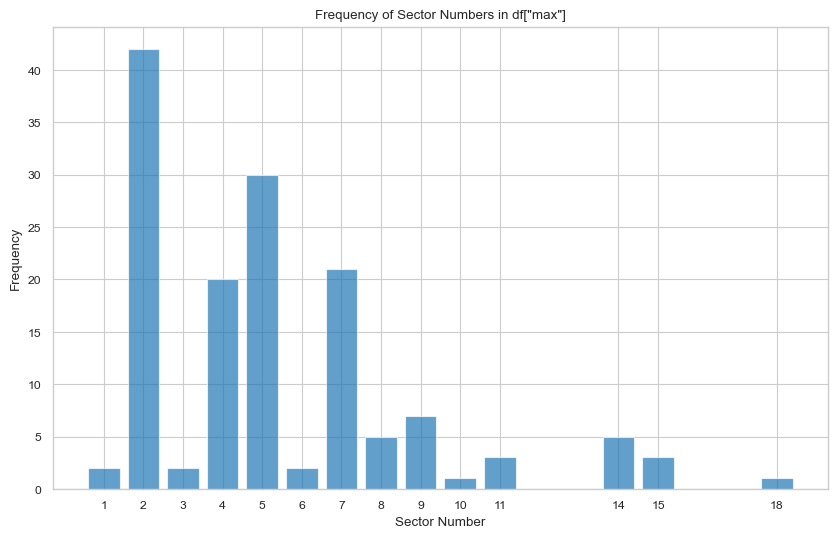

In [40]:
alls = np.unique(df['max'].values)
counts = df['max'].value_counts().sort_index()

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, align='center', alpha=0.7)
plt.xlabel('Sector Number')
plt.ylabel('Frequency')
plt.title('Frequency of Sector Numbers in df["max"]')
plt.xticks(counts.index)
plt.show()

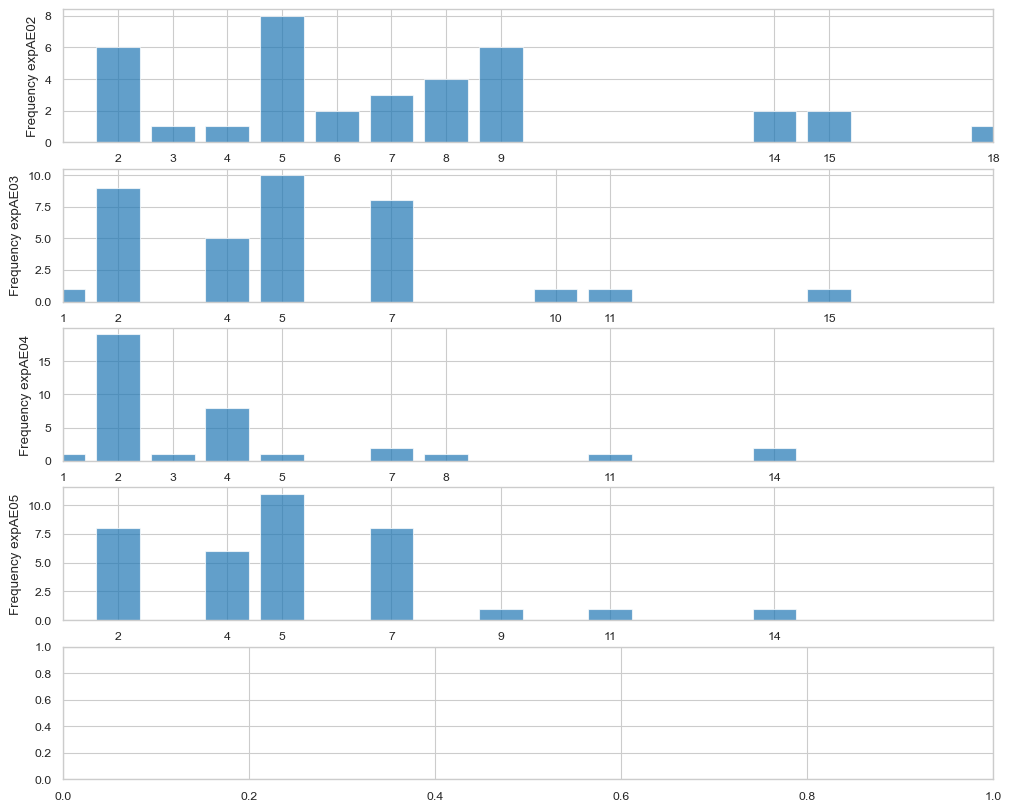

In [41]:
# for the 4 different exp
expsonly = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
f,ax = plt.subplots(5,1,figsize = (12,10))
# for i,exp in enumerate(expsonly):
for i,exp in enumerate(expnames):
    
    dfe = df[df.Experiment == exp]
    alls = np.unique(dfe['max'].values)
    counts = dfe['max'].value_counts().sort_index()


    ax[i].bar(counts.index, counts.values, align='center', alpha=0.7)
 
    ax[i].set_ylabel('Frequency '+exp)
    ax[i].set_xticks(counts.index)
    ax[i].set_xlim([1,18])

   
# ax[i].set_xlabel('Sector Number')
   


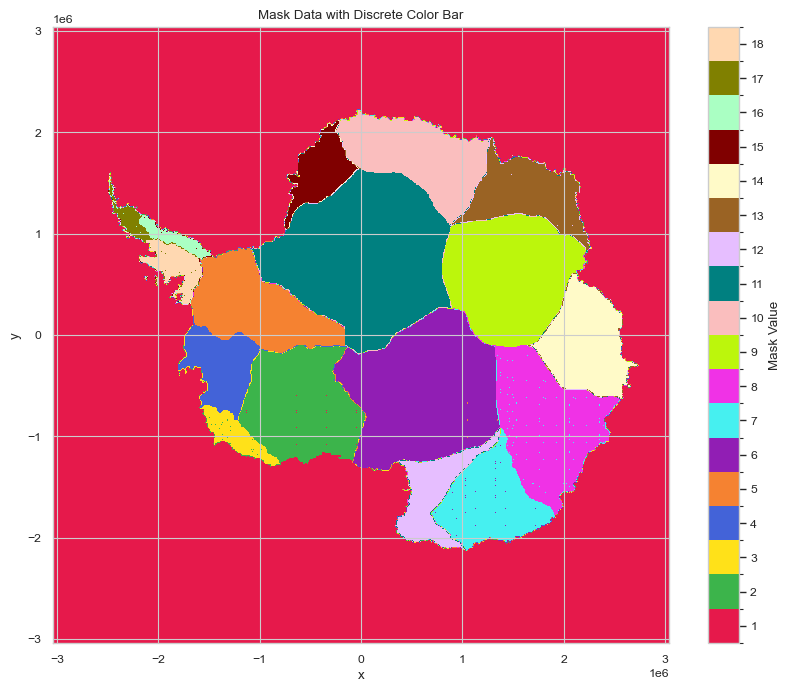

In [42]:


dataset = xr.open_dataset(pth_ismip6+'masks/sectors_8km_iceonly.nc')
# Get the mask data and coordinates
mask_data = dataset.variables['sectors'][:]
x_values = dataset.variables['x'][:]
y_values = dataset.variables['y'][:]
# Define a list of 18 distinct colors
colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', 
    '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', 
    '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1'
]

# Create a ListedColormap
cmap = ListedColormap(colors)

# Define the boundaries and normalization for the colormap
bounds = np.arange(1, 20)  # Boundaries for 18 regions (1 to 18)
norm = BoundaryNorm(bounds, cmap.N)

# Plot the mask data with the discrete colormap
plt.figure(figsize=(10, 8))
plt.imshow(mask_data, origin='lower', extent=[x_values[0], x_values[-1], y_values[0], y_values[-1]], cmap=cmap, norm=norm)

# Add a colorbar with discrete values
cbar = plt.colorbar(ticks=np.arange(1, 19))
cbar.set_label('Mask Value')
cbar.set_ticks(np.arange(1.5, 19.5))
cbar.set_ticklabels(np.arange(1, 19))

# Add labels and show the plot
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mask Data with Discrete Color Bar')
plt.grid(True)
plt.show()


### I would pick sector 2 for average melt but also sector 5 as th representative sector!!

